In [69]:
#Good for know. Will impove the chi2ndof when I add more events per sample. Closed for now. 

In [70]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/AllInOne_2022/Big_Resolution_dask.coffea"

sig_histo = util.load(f_sig) [0]


                                       mchi  dmchi   ctau    m1    m2  delta  \
sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  11.0    2.0  100.0  10.0  12.0    0.2   

                                                                        name  
sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  
                                       mchi  dmchi   ctau    m1    m2  delta  \
sig_2022_Mchi-22p0_dMchi-4p0_ctau-100  22.0    4.0  100.0  20.0  24.0    0.2   

                                                                        name  
sig_2022_Mchi-22p0_dMchi-4p0_ctau-100  sig_2022_Mchi-22p0_dMchi-4p0_ctau-100  
                                       mchi  dmchi   ctau    m1    m2  delta  \
sig_2022_Mchi-33p0_dMchi-6p0_ctau-100  33.0    6.0  100.0  30.0  36.0    0.2   

                                                                        name  
sig_2022_Mchi-33p0_dMchi-6p0_ctau-100  sig_2022_Mchi-33p0_dMchi-6p0_ctau-100  
                                       mchi

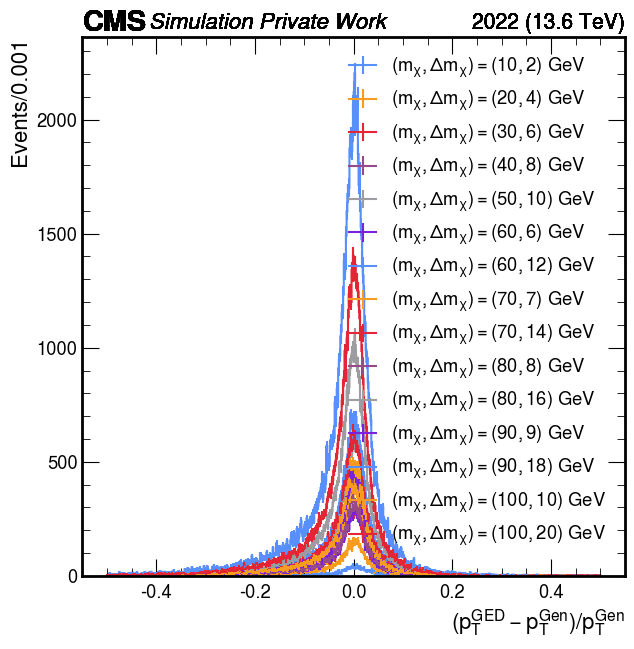

In [72]:
fig, ax = plt.subplots(figsize=(7,7))

# Plot settings
plot_dict = {
    'variable':'res_GED_gen',
    'cut': 'cut1',
    'year': 2022
}
style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points
samples = {
    10: 
    {
        
        0.2: [100],
    },
    20: 
    {
        
        0.2: [100],
        
    },
    30: 
    {
       
        0.2: [100]
    },
    40: 
    {
        0.2: [100],
    },
    50:
    {
        
        0.2: [100],
    },
    60:
    {
        
         0.1: [100],
         0.2: [100]
    
    },
    70:
    {    0.1: [100],
         0.2: [100],
    },
    80:
    {    0.1: [100],
         0.2: [100],
    },
    90:
    {    0.1: [100],
         0.2: [100],
    },
    100:
    {    0.1: [100],
         0.2: [100],
    }
 
}

h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_1D_return_histo(sig_histo, m1, delta, ctau, plot_dict, style_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
            else:
                h_sum_lpt += h_lpt


counts_lpt = h_sum_lpt.values()
edges_lpt = h_sum_lpt.axes[0].edges

bin_x_lpt = (edges_lpt[1:]+edges_lpt[:-1])/2



variances_lpt = h_sum_lpt.variances()
yerr_lpt = np.sqrt(variances_lpt)

# Residual range used by curve_fit (this affects the fitted result).
fit_min = -0.30
fit_max =  0.30

# Residual x-axis range shown on each fit plot (display only).
plot_min = -0.50
plot_max =  0.50


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


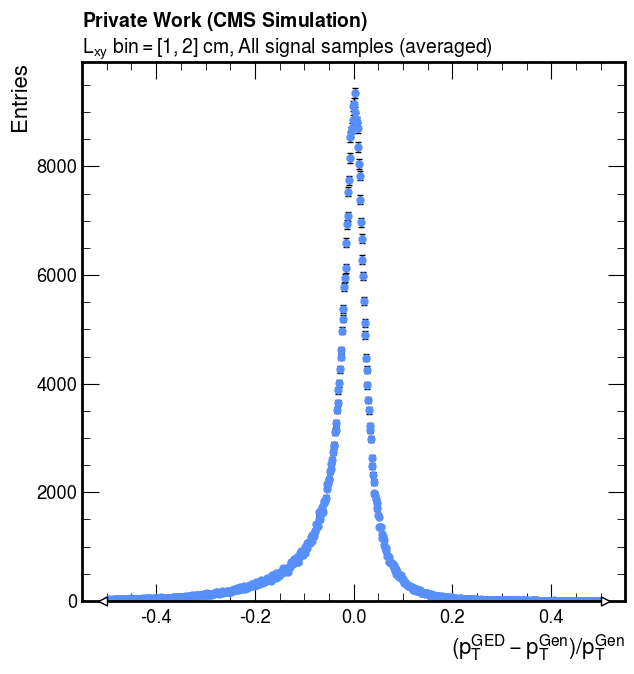

In [73]:
fig, ax = plt.subplots(figsize=(7,7))

mplhep.histplot(h_sum_lpt, histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black')

plt.xlabel(r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

plt.title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$"
    "\n"
    r"$\mathrm{L_{xy}\ bin = [1,2]\ cm, All\ signal\ samples\ (averaged) }$",
    fontsize=14,
    loc="left",
)

plt.show()

In [74]:
# ============================================================
# DSCB MODEL -- unchanged from the original notebook
# ============================================================

def double_cb(x, u, sig, nl, a_l, nr, a_r, N):
    t = (x-u)/sig
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t >= -al) & (t <= ar)
    right_tail = t > ar

    y = np.empty_like(t)
    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl/al)**nl * np.exp(-0.5*al**2)
    B_L = (nl/al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr/ar)**nr * np.exp(-0.5*ar**2)
    B_R = (nr/ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y

In [75]:
#2. Put your data


xdata = bin_x_lpt
ydata = counts_lpt

mask = (ydata > 0) & (xdata >= fit_min) & (xdata <= fit_max)
ydata_new =ydata[mask]


xdata_new = xdata[mask]

yerr_new_lpt = yerr_lpt[mask]



chi2ndof= 2.2898132049067508


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


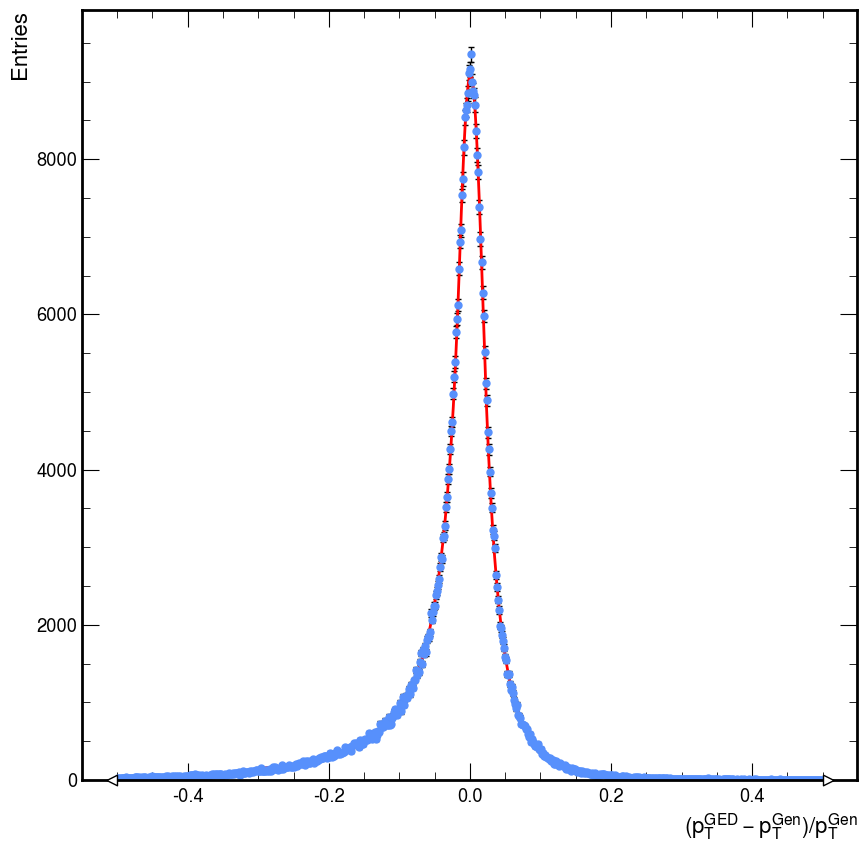

mean  = 0.00087 ± 0.00007
sigma = 0.01982 ± 0.00013
nl    = 2.00000 ± 0.01735
al    = 0.79633 ± 0.00661
nr    = 4.02826 ± 0.05450
ar    = 0.98354 ± 0.00871
N     = 9093.03831 ± 27.74274


In [76]:
#3. Curve fit 
from scipy.optimize import curve_fit
mean0 = np.average(xdata_new, weights=ydata_new)
sigma0 = np.sqrt(np.average((xdata_new-mean0)**2, weights=ydata_new))

   # [mean, sigma, nl, al, nr, ar, N]:  [0.0002642, 0.02177, 1, 0.2, 1, 0.2,data["y_new_data"].max()]
initial_guess = [mean0, sigma0, 1, 0.2, 1, 0.2, ydata_new.max()]

lower = [xdata_new.min(), 1e-5, 0.5, 0.05, 0.1, 0.05, 0]
upper = [xdata_new.max(), (xdata_new.max()-xdata_new.min()), 2, 1, 5, 2, 5*ydata_new.max()]

popt, pcov = curve_fit(double_cb, xdata_new, ydata_new, p0=initial_guess, sigma=yerr_new_lpt, absolute_sigma=True, bounds=(lower, upper), maxfev=20000)
perr = np.sqrt(np.diag(pcov))

yp = double_cb(xdata_new, *popt)

eq = (ydata_new-yp)/(yerr_new_lpt)
chi2 = np.sum(eq**2)

ndof = len(ydata_new) - len(popt)

chi2ndof = chi2/ndof
print ("chi2ndof=", chi2ndof)

names = ["mean", "sigma", "nl", "al", "nr", "ar", "N"]

mplhep.histplot(h_sum_lpt, histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black', label='Histogram')


plt.plot(xdata_new, double_cb(xdata_new, *popt), label='Double Crystal Ball Fit', color='red', linewidth=2)

plt.xlabel(r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

plt.show()



for name, value, error in zip(names, popt, perr):
    print(f"{name:5s} = {value:.5f} ± {error:.5f}")



# mean0 = np.average(xdata_new, weights=ydata_new)
# sigma0 = np.sqrt(np.average((xdata_new-mean0)**2, weights=ydata_new))

# initial_guess = [mean0, sigma0, 1, 0.2, 1, 0.2, ydata_new.max()]

# lower = [xdata_new.min(), 1e-5, 0.5, 0.05, 0.1, 0.05, 0]
# upper = [xdata_new.max(), (xdata_new.max()-xdata_new.min()), 2, 1, 5, 2, 5*ydata_new.max()]


# popt, pcov = curve_fit(double_cb, xdata_new, ydata_new, p0=initial_guess, sigma=ydata_new, absolute_sigma=True, bounds=(lower, upper), maxfev=20000)
# perr = np.sqrt(np.diag(pcov))

# # initial_guess = [0.000672, 0.02265, 30, 0.2, 10, 0.2,ydata_new.max()] #[mean, sigma, nl, al, nr, ar, N]

# # popt, pcov = curve_fit(double_cb, xdata_new, ydata_new, p0=initial_guess, sigma=yerr_new_lpt, absolute_sigma=True)

# mplhep.histplot(h_sum_lpt, histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black', label='Histogram')

# plt.plot(xdata_new, double_cb(xdata_new, *popt), label='Double Crystal Ball Fit', color='red', linewidth=2)


# plt.xlabel(r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
# plt.ylabel("Entries")

# print ("[mean, sigma, nl, al, nr, ar, N]=", popt)

# yp = double_cb(xdata_new, *popt)

# eq = (ydata_new-yp)/(yerr_new_lpt)
# chi2 = np.sum(eq**2)

# ndof = len(ydata_new) - len(popt)

# chi2ndof = chi2/ndof
# print ("chi2ndof=", chi2ndof)

# perr = np.sqrt(np.diag(pcov))
# names = ["mean", "sigma", "nl", "al", "nr", "ar", "N"]

# for name, value, error in zip(names, popt, perr):
#     print(f"{name:5s} = {value:.5f} ± {error:.5f}")



In [77]:
perr = np.sqrt(np.diag(pcov))
names = ["mean", "sigma", "nl", "al", "nr", "ar", "N"]

for name, value, error in zip(names, popt, perr):
    print(f"{name:5s} = {value:.5f} ± {error:.5f}")

mean  = 0.00087 ± 0.00007
sigma = 0.01982 ± 0.00013
nl    = 2.00000 ± 0.01735
al    = 0.79633 ± 0.00661
nr    = 4.02826 ± 0.05450
ar    = 0.98354 ± 0.00871
N     = 9093.03831 ± 27.74274
